# Outcome missingness

This section describes the data source and extraction steps for the primary outcome. The file loaded below is the tidy national country-year extract from Eurostat table `hlth_silc_08`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
YEARS = list(range(2008, 2026))
data_path = PROJECT_ROOT / 'data' / 'processed' / 'country_year_outcome.csv'
outputs_dir = PROJECT_ROOT / 'outputs'

df = pd.read_csv(data_path)
df.head()

,geo,year,unmet_need_pc,status
0,AL,2017,13.1,NaN
1,AL,2018,14.8,NaN
2,AL,2019,14.6,NaN
3,AL,2020,10.6,NaN
4,AL,2021,10.7,NaN


In [2]:
# build country-year table with one row per geo and time
base = pd.MultiIndex.from_product(
    [sorted(df['geo'].unique()), YEARS],
    names=['geo', 'year'],
).to_frame(index=False)
observed = df[['geo', 'year', 'unmet_need_pc']].copy()
observed['observed'] = observed['unmet_need_pc'].notna().astype(int)
availability = base.merge(observed[['geo', 'year', 'observed']], on=['geo', 'year'], how='left')
availability['observed'] = availability['observed'].fillna(0).astype(int)
availability.head()

,geo,year,observed
0,AL,2008,0
1,AL,2009,0
2,AL,2010,0
3,AL,2011,0
4,AL,2012,0


In [3]:
country_coverage = (
    availability.groupby('geo', as_index=False)['observed']
    .sum()
    .rename(columns={'observed': 'non_missing_years'})
    .sort_values(['non_missing_years', 'geo'])
)
country_coverage

,geo,non_missing_years
36,XK,2
0,AL,7
22,ME,11
35,UK,11
17,IS,13
30,RS,13
23,MK,15
14,HR,16
4,CH,17
18,IT,17


In [4]:
matrix = availability.pivot(index='geo', columns='year', values='observed').sort_index()
matrix.to_csv(outputs_dir / 'outcome_availability_matrix.csv')
country_coverage.to_csv(outputs_dir / 'outcome_country_coverage_notebook.csv', index=False)
matrix

year,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
geo,,,,,,,,,,,,,,,,,,
AL,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,0,0
AT,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
BE,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
BG,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
CH,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0
CY,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
CZ,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
DE,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
DK,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


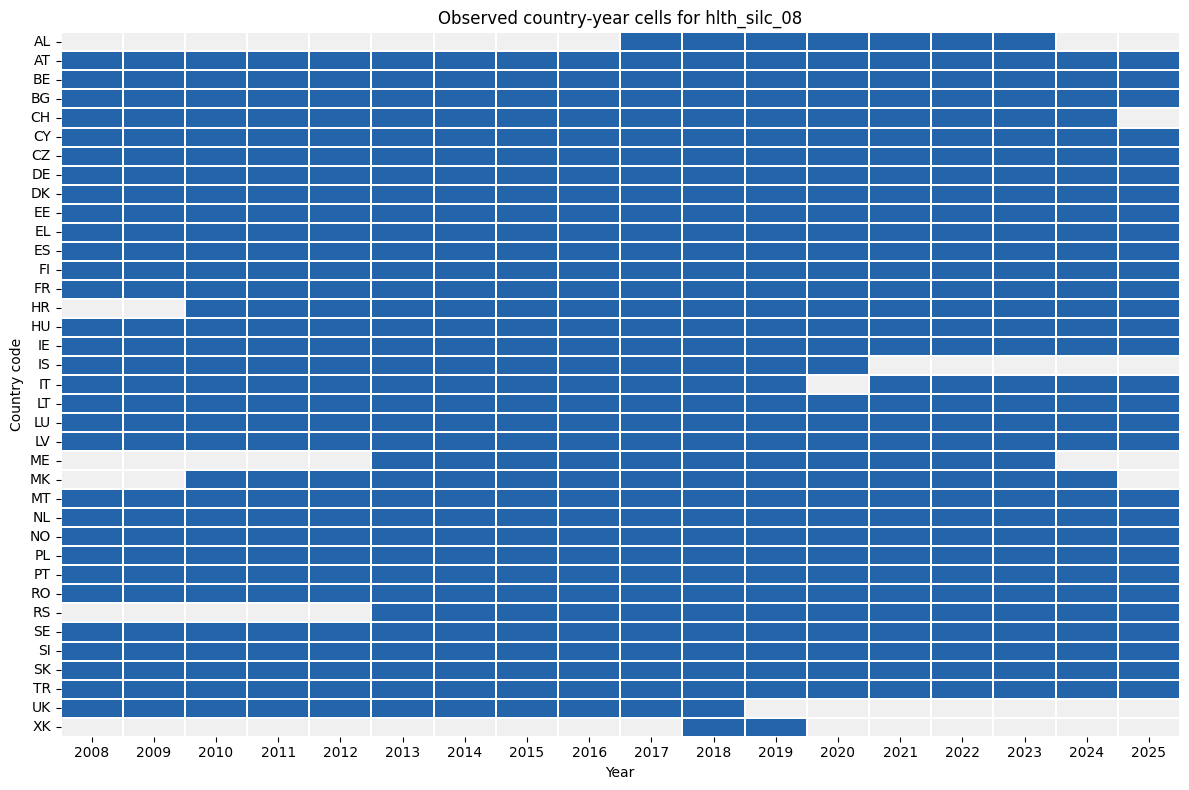

In [5]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    matrix,
    cmap=sns.color_palette(['#f0f0f0', '#2364aa']),
    cbar=False,
    linewidths=0.15,
    linecolor='white',
)
plt.xlabel('Year')
plt.ylabel('Country code')
plt.title('Observed country-year cells for hlth_silc_08')
plt.tight_layout()
plt.savefig(outputs_dir / 'outcome_missingness_heatmap_notebook.png', dpi=180)
plt.show()

The table and heatmap describe observed and missing cells only. They do not report inference.